# Projet Deep Learning — Partie III : RNN, LSTM, GRU et Seq2Seq

Ce notebook Colab implémente une mini-expérience complète sur un corpus réel **français → anglais** :

- préparation du dataset ;
- tokenisation, vocabulaire, padding, masking et mini-lots ;
- modèles Seq2Seq avec encodeur-décodeur récurrent ;
- comparaison entre **RNN simple**, **LSTM** et **GRU** ;
- teacher forcing ;
- gradient clipping ;
- décodage glouton ;
- beam search ;
- évaluation par loss, perplexité et BLEU.

> Conseil Colab : `Exécution` → `Modifier le type d'exécution` → `GPU`.

Présentation du projet Seq2Seq et comparaison RNN/LSTM/GRU.

In [ ]:
# ============================================================
# 1) Installation et imports
# ============================================================

!pip -q install nltk tqdm

import os
import re
import math
import time
import random
import zipfile
import unicodedata
from collections import Counter
from dataclasses import dataclass

import requests
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

Installation des dépendances et imports des bibliothèques.

In [ ]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DEVICE =", DEVICE)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("Aucun GPU détecté")

DEVICE = cuda
GPU : Tesla T4


Vérification et affichage de l'appareil d'exécution (GPU/CPU).

In [ ]:
import torch

print("CUDA disponible :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU utilisé :", torch.cuda.get_device_name(0))
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("DEVICE =", DEVICE)

CUDA disponible : True
GPU utilisé : Tesla T4
DEVICE = cuda


Confirmation de l'appareil d'exécution (GPU/CPU).

In [ ]:
# ============================================================
# 2) Hyperparamètres principaux
# ============================================================

# Pour un entraînement rapide dans Colab.
# Tu peux augmenter MAX_PAIRS et EPOCHS si tu as le temps.
MAX_PAIRS = 12000
MAX_LEN = 10
MIN_FREQ = 2
MAX_VOCAB_SIZE = 12000

BATCH_SIZE = 64
EMB_DIM = 128
HID_DIM = 256
NUM_LAYERS = 1
DROPOUT = 0.2

EPOCHS = 5
LEARNING_RATE = 1e-3
CLIP_VALUE = 1.0

# Pour réduire le temps d'évaluation BLEU.
BLEU_EVAL_SAMPLES = 200

print("Device:", DEVICE)

Device: cuda


Définition des hyperparamètres clés du modèle et de l'entraînement.

In [ ]:
# ============================================================
# 3) Téléchargement du dataset français-anglais
# ============================================================

def download_file(url, out_path):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers, timeout=60)
    response.raise_for_status()
    with open(out_path, "wb") as f:
        f.write(response.content)

zip_path = "fra-eng.zip"

# Source ManyThings/Tatoeba, avec miroir Google en secours.
urls = [
    "https://www.manythings.org/anki/fra-eng.zip",
    "http://storage.googleapis.com/download.tensorflow.org/data/fra-eng.zip"
]

if not os.path.exists(zip_path):
    downloaded = False
    for url in urls:
        try:
            print("Téléchargement depuis :", url)
            download_file(url, zip_path)
            downloaded = True
            break
        except Exception as e:
            print("Échec avec", url, ":", repr(e))
    if not downloaded:
        raise RuntimeError("Impossible de télécharger le dataset.")

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("fra-eng")

# Recherche automatique du fichier .txt
txt_files = []
for root, dirs, files in os.walk("fra-eng"):
    for f in files:
        if f.endswith(".txt"):
            txt_files.append(os.path.join(root, f))

print(txt_files)

txt_path = [f for f in txt_files if f.endswith("fra.txt")][0]
print("Fichier dataset utilisé :", txt_path)

['fra-eng/_about.txt', 'fra-eng/fra.txt']
Fichier dataset utilisé : fra-eng/fra.txt


Téléchargement et extraction du dataset de traduction fra-eng.

In [ ]:
# ============================================================
# 4) Nettoyage, tokenisation simple et chargement des paires
# ============================================================

def unicode_to_ascii(s):
    return "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )

def normalize_text(s):
    s = unicode_to_ascii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def tokenize(s):
    return s.split()

# Forcer l'utilisation du vrai fichier dataset
txt_path = "fra-eng/fra.txt"

print("Fichier utilisé :", txt_path)

# Afficher quelques lignes pour vérifier le format
with open(txt_path, encoding="utf-8") as f:
    for i in range(5):
        print(f.readline().strip())

pairs = []

with open(txt_path, encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("\t")

        if len(parts) < 2:
            continue

        # Format : anglais \t français
        eng = normalize_text(parts[0])
        fra = normalize_text(parts[1])

        src_tokens = tokenize(fra)  # source = français
        trg_tokens = tokenize(eng)  # cible = anglais

        # On garde seulement les phrases pas trop longues
        if 1 <= len(src_tokens) <= MAX_LEN and 1 <= len(trg_tokens) <= MAX_LEN:
            pairs.append((src_tokens, trg_tokens))

random.shuffle(pairs)
pairs = pairs[:MAX_PAIRS]

print("Nombre de paires utilisées :", len(pairs))

if len(pairs) > 0:
    print("Exemple source FR :", " ".join(pairs[0][0]))
    print("Exemple cible EN :", " ".join(pairs[0][1]))
else:
    print("Aucune paire trouvée. Essaie d'augmenter MAX_LEN.")

Fichier utilisé : fra-eng/fra.txt
Go.	Va !
Hi.	Salut !
Run!	Cours !
Run!	Courez !
Who?	Qui ?
Nombre de paires utilisées : 12000
Exemple source FR : c est amusant de jouer aux cartes .
Exemple cible EN : playing cards is fun .


Prétraitement du texte et chargement des paires de phrases filtrées.

In [ ]:
# ============================================================
# 5) Vocabulaire avec tokens spéciaux
# ============================================================

PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
UNK_TOKEN = "<UNK>"

class Vocab:
    def __init__(self, token_lists, min_freq=1, max_size=None):
        counter = Counter()
        for tokens in token_lists:
            counter.update(tokens)

        self.itos = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
        for token, freq in counter.most_common():
            if freq < min_freq:
                continue
            if token in self.itos:
                continue
            self.itos.append(token)
            if max_size is not None and len(self.itos) >= max_size:
                break

        self.stoi = {token: idx for idx, token in enumerate(self.itos)}
        self.pad_idx = self.stoi[PAD_TOKEN]
        self.sos_idx = self.stoi[SOS_TOKEN]
        self.eos_idx = self.stoi[EOS_TOKEN]
        self.unk_idx = self.stoi[UNK_TOKEN]

    def __len__(self):
        return len(self.itos)

    def encode(self, tokens, add_sos_eos=True):
        ids = [self.stoi.get(t, self.unk_idx) for t in tokens]
        if add_sos_eos:
            ids = [self.sos_idx] + ids + [self.eos_idx]
        return ids

    def decode(self, ids, remove_special=True):
        tokens = []
        for idx in ids:
            token = self.itos[int(idx)]
            if remove_special and token in {PAD_TOKEN, SOS_TOKEN, EOS_TOKEN}:
                continue
            if remove_special and token == UNK_TOKEN:
                tokens.append(token)
            else:
                tokens.append(token)
        return tokens

# Split train/validation/test
n = len(pairs)
n_train = int(0.8 * n)
n_val = int(0.1 * n)

train_pairs = pairs[:n_train]
val_pairs = pairs[n_train:n_train+n_val]
test_pairs = pairs[n_train+n_val:]

src_vocab = Vocab([src for src, trg in train_pairs], min_freq=MIN_FREQ, max_size=MAX_VOCAB_SIZE)
trg_vocab = Vocab([trg for src, trg in train_pairs], min_freq=MIN_FREQ, max_size=MAX_VOCAB_SIZE)

print("Train/Val/Test :", len(train_pairs), len(val_pairs), len(test_pairs))
print("Taille vocab source FR :", len(src_vocab))
print("Taille vocab cible EN :", len(trg_vocab))

Train/Val/Test : 9600 1200 1200
Taille vocab source FR : 2718
Taille vocab cible EN : 2230


Construction des vocabulaires source et cible, et division du dataset.

In [ ]:
# ============================================================
# 6) Dataset, padding, masquage et mini-lots
# ============================================================

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, trg_vocab):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_tokens, trg_tokens = self.pairs[idx]
        src_ids = self.src_vocab.encode(src_tokens, add_sos_eos=True)
        trg_ids = self.trg_vocab.encode(trg_tokens, add_sos_eos=True)
        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(trg_ids, dtype=torch.long)

def pad_sequences(sequences, pad_idx):
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    max_len = max(lengths).item()
    batch = torch.full((len(sequences), max_len), pad_idx, dtype=torch.long)
    for i, seq in enumerate(sequences):
        batch[i, :len(seq)] = seq
    return batch, lengths

def collate_fn(batch):
    src_seqs, trg_seqs = zip(*batch)
    src_batch, src_lengths = pad_sequences(src_seqs, src_vocab.pad_idx)
    trg_batch, trg_lengths = pad_sequences(trg_seqs, trg_vocab.pad_idx)
    return src_batch, src_lengths, trg_batch, trg_lengths

train_loader = DataLoader(
    TranslationDataset(train_pairs, src_vocab, trg_vocab),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    TranslationDataset(val_pairs, src_vocab, trg_vocab),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    TranslationDataset(test_pairs, src_vocab, trg_vocab),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

batch = next(iter(train_loader))
[src.shape for src in batch if hasattr(src, "shape")]

[torch.Size([64, 12]),
 torch.Size([64]),
 torch.Size([64, 12]),
 torch.Size([64])]

Préparation du dataset pour PyTorch : padding et DataLoaders.

In [ ]:
# ============================================================
# 7) Modèles : Encodeur, Décodeur et Seq2Seq
# ============================================================

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, num_layers, dropout, cell_type="gru", pad_idx=0):
        super().__init__()
        self.cell_type = cell_type.lower()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)

        rnn_cls = {
            "rnn": nn.RNN,
            "lstm": nn.LSTM,
            "gru": nn.GRU
        }[self.cell_type]

        self.rnn = rnn_cls(
            emb_dim,
            hid_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

    def forward(self, src, src_lengths):
        # src: [batch, src_len]
        embedded = self.dropout(self.embedding(src))

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            src_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        outputs, hidden = self.rnn(packed)
        return hidden


class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, num_layers, dropout, cell_type="gru", pad_idx=0):
        super().__init__()
        self.cell_type = cell_type.lower()
        self.output_dim = output_dim

        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)

        rnn_cls = {
            "rnn": nn.RNN,
            "lstm": nn.LSTM,
            "gru": nn.GRU
        }[self.cell_type]

        self.rnn = rnn_cls(
            emb_dim,
            hid_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc_out = nn.Linear(hid_dim, output_dim)

    def forward(self, input_seq, hidden):
        # input_seq: [batch, trg_len]
        embedded = self.dropout(self.embedding(input_seq))
        outputs, hidden = self.rnn(embedded, hidden)
        logits = self.fc_out(outputs)
        return logits, hidden

    def forward_step(self, input_token, hidden):
        # input_token: [batch]
        input_seq = input_token.unsqueeze(1)
        logits, hidden = self.forward(input_seq, hidden)
        return logits.squeeze(1), hidden


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, trg_pad_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.trg_pad_idx = trg_pad_idx

    def forward(self, src, src_lengths, trg):
        # Teacher forcing total : le décodeur reçoit les vrais tokens précédents.
        # trg: [batch, trg_len]
        hidden = self.encoder(src, src_lengths)

        decoder_input = trg[:, :-1]   # <SOS> y1 y2 ...
        logits, _ = self.decoder(decoder_input, hidden)

        return logits                 # prédiction de y1 y2 ... <EOS>

Définition des architectures Encoder, Decoder et Seq2Seq.

In [ ]:
# ============================================================
# 8) Fonctions d'entraînement, évaluation, perplexité
# ============================================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def grad_global_norm(parameters):
    total_norm_sq = 0.0
    for p in parameters:
        if p.grad is not None:
            param_norm = p.grad.detach().data.norm(2).item()
            total_norm_sq += param_norm ** 2
    return total_norm_sq ** 0.5

def train_one_epoch(model, loader, optimizer, criterion, clip=None):
    model.train()
    total_loss = 0.0
    total_tokens = 0
    grad_norms = []

    for src, src_lengths, trg, trg_lengths in tqdm(loader, leave=False):
        src = src.to(DEVICE)
        src_lengths = src_lengths.to(DEVICE)
        trg = trg.to(DEVICE)

        optimizer.zero_grad()

        logits = model(src, src_lengths, trg)
        target = trg[:, 1:]  # y1 y2 ... <EOS>

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            target.reshape(-1)
        )

        loss.backward()

        norm_before_clip = grad_global_norm(model.parameters())
        grad_norms.append(norm_before_clip)

        if clip is not None:
            nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        non_pad_tokens = (target != trg_vocab.pad_idx).sum().item()
        total_loss += loss.item() * non_pad_tokens
        total_tokens += non_pad_tokens

    return total_loss / max(total_tokens, 1), float(np.mean(grad_norms)), float(np.max(grad_norms))


@torch.no_grad()
def evaluate_loss(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    for src, src_lengths, trg, trg_lengths in loader:
        src = src.to(DEVICE)
        src_lengths = src_lengths.to(DEVICE)
        trg = trg.to(DEVICE)

        logits = model(src, src_lengths, trg)
        target = trg[:, 1:]

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            target.reshape(-1)
        )

        non_pad_tokens = (target != trg_vocab.pad_idx).sum().item()
        total_loss += loss.item() * non_pad_tokens
        total_tokens += non_pad_tokens

    avg_loss = total_loss / max(total_tokens, 1)
    ppl = math.exp(min(avg_loss, 20))
    return avg_loss, ppl


def build_model(cell_type):
    encoder = Encoder(
        input_dim=len(src_vocab),
        emb_dim=EMB_DIM,
        hid_dim=HID_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        cell_type=cell_type,
        pad_idx=src_vocab.pad_idx
    )

    decoder = Decoder(
        output_dim=len(trg_vocab),
        emb_dim=EMB_DIM,
        hid_dim=HID_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        cell_type=cell_type,
        pad_idx=trg_vocab.pad_idx
    )

    model = Seq2Seq(encoder, decoder, trg_pad_idx=trg_vocab.pad_idx).to(DEVICE)
    return model

Fonctions d'entraînement, d'évaluation (loss, perplexité) et de construction de modèle.

In [ ]:
# ============================================================
# 9) Entraînement comparatif : RNN simple, LSTM, GRU
# ============================================================

def train_model(cell_type, epochs=EPOCHS, clip=CLIP_VALUE):
    model = build_model(cell_type)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss(ignore_index=trg_vocab.pad_idx)

    history = []
    best_val_loss = float("inf")
    best_state = None

    print(f"\n===== Modèle {cell_type.upper()} =====")
    print("Nombre de paramètres :", count_parameters(model))

    for epoch in range(1, epochs + 1):
        start = time.time()

        train_loss, grad_mean, grad_max = train_one_epoch(
            model, train_loader, optimizer, criterion, clip=clip
        )
        val_loss, val_ppl = evaluate_loss(model, val_loader, criterion)

        elapsed = time.time() - start

        row = {
            "cell_type": cell_type.upper(),
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_ppl": val_ppl,
            "grad_norm_mean": grad_mean,
            "grad_norm_max": grad_max,
            "time_sec": elapsed
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d} | "
            f"train loss={train_loss:.4f} | "
            f"val loss={val_loss:.4f} | "
            f"val ppl={val_ppl:.2f} | "
            f"grad max={grad_max:.2f} | "
            f"time={elapsed:.1f}s"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


models = {}
histories = []

for cell in ["rnn", "lstm", "gru"]:
    model, hist = train_model(cell, epochs=EPOCHS, clip=CLIP_VALUE)
    models[cell] = model
    histories.append(hist)

history_df = pd.concat(histories, ignore_index=True)
history_df


===== Modèle RNN =====
Nombre de paramètres : 1404086


  0%|          | 0/150 [00:00<?, ?it/s]

Epoch 01 | train loss=4.3323 | val loss=3.6217 | val ppl=37.40 | grad max=1.91 | time=2.7s


  0%|          | 0/150 [00:00<?, ?it/s]

Epoch 02 | train loss=3.4774 | val loss=3.3141 | val ppl=27.50 | grad max=1.12 | time=1.6s


...

  0%|          | 0/150 [00:00<?, ?it/s]

Epoch 04 | train loss=2.5930 | val loss=2.6513 | val ppl=14.17 | grad max=0.64 | time=1.7s


  0%|          | 0/150 [00:00<?, ?it/s]

Epoch 05 | train loss=2.3554 | val loss=2.5245 | val ppl=12.48 | grad max=0.62 | time=1.6s


,cell_type,epoch,train_loss,val_loss,val_ppl,grad_norm_mean,grad_norm_max,time_sec
0,RNN,1,4.332271,3.621746,37.402813,0.757634,1.909154,2.689404
1,RNN,2,3.477370,3.314063,27.496619,0.718336,1.116482,1.597500
2,RNN,3,3.210796,3.192197,24.341838,0.730234,1.103279,2.122714
3,RNN,4,3.033968,3.098869,22.172856,0.715810,1.069154,1.726946
4,RNN,5,2.877216,3.033747,20.774921,0.768735,1.066489,1.530410
5,LSTM,1,4.453473,3.660068,38.863975,0.606509,1.634677,1.701989
6,LSTM,2,3.473201,3.206277,24.687012,0.482496,0.603369,1.665419
7,LSTM,3,3.087353,2.960381,19.305322,0.499611,0.712337,1.662314
8,LSTM,4,2.814516,2.779680,16.113856,0.510873,0.631407,1.674095
9,LSTM,5,2.594746,2.643457,14.061725,0.523009,0.615359,2.170836


Entraînement comparatif des modèles RNN, LSTM et GRU.

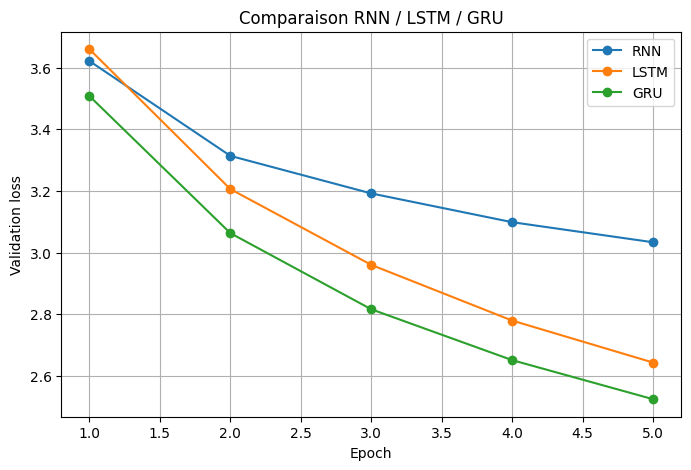

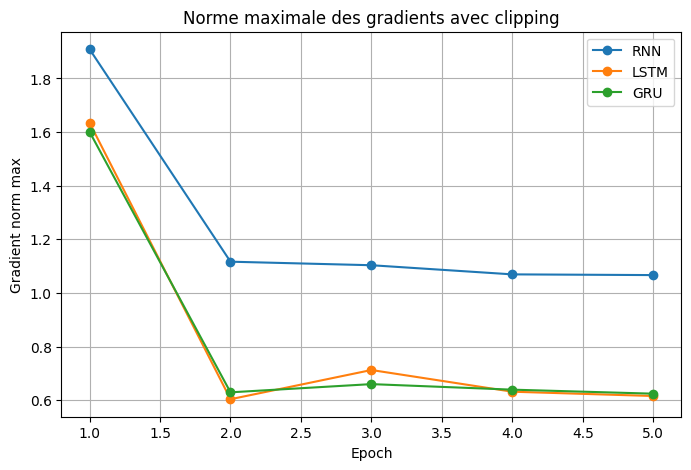

In [ ]:
# ============================================================
# 10) Visualisation des courbes d'apprentissage
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for cell_type in history_df["cell_type"].unique():
    sub = history_df[history_df["cell_type"] == cell_type]
    plt.plot(sub["epoch"], sub["val_loss"], marker="o", label=cell_type)

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Comparaison RNN / LSTM / GRU")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
for cell_type in history_df["cell_type"].unique():
    sub = history_df[history_df["cell_type"] == cell_type]
    plt.plot(sub["epoch"], sub["grad_norm_max"], marker="o", label=cell_type)

plt.xlabel("Epoch")
plt.ylabel("Gradient norm max")
plt.title("Norme maximale des gradients avec clipping")
plt.legend()
plt.grid(True)
plt.show()

Visualisation des courbes de loss et des normes de gradient.

In [ ]:
# ============================================================
# 11) Expérience spécifique : effet du gradient clipping
# ============================================================

def clipping_experiment(cell_type="rnn", epochs=1):
    results = []

    for clip in [None, CLIP_VALUE]:
        model = build_model(cell_type)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE * 2)
        criterion = nn.CrossEntropyLoss(ignore_index=trg_vocab.pad_idx)

        print("\nExpérience gradient clipping")
        print("Cellule :", cell_type.upper(), "| clipping :", clip)

        train_loss, grad_mean, grad_max = train_one_epoch(
            model, train_loader, optimizer, criterion, clip=clip
        )
        val_loss, val_ppl = evaluate_loss(model, val_loader, criterion)

        results.append({
            "cell_type": cell_type.upper(),
            "clip": "sans clipping" if clip is None else f"clip={clip}",
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_ppl": val_ppl,
            "grad_norm_mean": grad_mean,
            "grad_norm_max": grad_max
        })

    return pd.DataFrame(results)

clipping_df = clipping_experiment(cell_type="rnn", epochs=1)
clipping_df


Expérience gradient clipping
Cellule : RNN | clipping : None


  0%|          | 0/150 [00:00<?, ?it/s]


Expérience gradient clipping
Cellule : RNN | clipping : 1.0


  0%|          | 0/150 [00:00<?, ?it/s]

,cell_type,clip,train_loss,val_loss,val_ppl,grad_norm_mean,grad_norm_max
0,RNN,sans clipping,4.124445,3.466258,32.016718,0.752306,1.651550
1,RNN,clip=1.0,4.086163,3.436258,31.070462,0.743208,1.748228


Expérience pour étudier l'impact du gradient clipping.

In [ ]:
# ============================================================
# 12) Décodage glouton
# ============================================================

def preprocess_src_sentence(sentence):
    tokens = tokenize(normalize_text(sentence))
    ids = src_vocab.encode(tokens, add_sos_eos=True)
    src = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(DEVICE)
    src_len = torch.tensor([len(ids)], dtype=torch.long).to(DEVICE)
    return src, src_len, tokens

@torch.no_grad()
def greedy_decode(model, sentence, max_len=20):
    model.eval()
    src, src_len, src_tokens = preprocess_src_sentence(sentence)

    hidden = model.encoder(src, src_len)

    input_token = torch.tensor([trg_vocab.sos_idx], dtype=torch.long).to(DEVICE)
    generated_ids = []

    for _ in range(max_len):
        logits, hidden = model.decoder.forward_step(input_token, hidden)
        next_token = logits.argmax(dim=-1)
        next_id = next_token.item()

        if next_id == trg_vocab.eos_idx:
            break

        generated_ids.append(next_id)
        input_token = next_token

    return " ".join(trg_vocab.decode(generated_ids))


# Exemple avec le meilleur modèle selon la validation
best_cell = history_df.groupby("cell_type")["val_loss"].min().idxmin().lower()
best_model = models[best_cell]

print("Meilleur modèle selon val_loss :", best_cell.upper())

examples = [
    "je suis etudiant .",
    "bonjour !",
    "je t aime .",
    "nous sommes prets .",
    "il est tres gentil ."
]

for s in examples:
    print("FR :", s)
    print("EN greedy :", greedy_decode(best_model, s))
    print("-" * 50)

Meilleur modèle selon val_loss : GRU
FR : je suis etudiant .
EN greedy : i m going .
--------------------------------------------------
FR : bonjour !
EN greedy : go .
--------------------------------------------------
FR : je t aime .
EN greedy : i ll be a <UNK> .
--------------------------------------------------
FR : nous sommes prets .
EN greedy : we re going .
--------------------------------------------------
FR : il est tres gentil .
EN greedy : he is very good .
--------------------------------------------------


Implémentation et test du décodage glouton.

In [ ]:
# ============================================================
# 13) Beam search
# ============================================================

def detach_hidden(hidden):
    if isinstance(hidden, tuple):
        return tuple(h.detach() for h in hidden)
    return hidden.detach()

def clone_hidden(hidden):
    if isinstance(hidden, tuple):
        return tuple(h.clone() for h in hidden)
    return hidden.clone()

@torch.no_grad()
def beam_search_decode(model, sentence, beam_size=3, max_len=20, length_penalty=0.7):
    model.eval()
    src, src_len, src_tokens = preprocess_src_sentence(sentence)
    encoder_hidden = model.encoder(src, src_len)

    # Chaque beam = (tokens générés, log_prob, hidden, ended)
    beams = [([], 0.0, encoder_hidden, False)]

    for _ in range(max_len):
        candidates = []

        for tokens, log_prob, hidden, ended in beams:
            if ended:
                candidates.append((tokens, log_prob, hidden, ended))
                continue

            last_token = trg_vocab.sos_idx if len(tokens) == 0 else tokens[-1]
            input_token = torch.tensor([last_token], dtype=torch.long).to(DEVICE)

            logits, new_hidden = model.decoder.forward_step(input_token, hidden)
            log_probs = torch.log_softmax(logits, dim=-1)

            top_log_probs, top_indices = torch.topk(log_probs, beam_size, dim=-1)

            for lp, idx in zip(top_log_probs[0], top_indices[0]):
                idx = idx.item()
                new_tokens = tokens + [idx]
                new_log_prob = log_prob + lp.item()
                ended_new = idx == trg_vocab.eos_idx

                candidates.append(
                    (new_tokens, new_log_prob, clone_hidden(new_hidden), ended_new)
                )

        def score_fn(item):
            tokens, log_prob, hidden, ended = item
            length = max(1, len(tokens))
            return log_prob / (length ** length_penalty)

        beams = sorted(candidates, key=score_fn, reverse=True)[:beam_size]

        if all(ended for _, _, _, ended in beams):
            break

    best_tokens, best_score, _, _ = beams[0]
    best_tokens = [t for t in best_tokens if t != trg_vocab.eos_idx]
    return " ".join(trg_vocab.decode(best_tokens))


for s in examples:
    print("FR :", s)
    print("EN greedy :", greedy_decode(best_model, s))
    print("EN beam   :", beam_search_decode(best_model, s, beam_size=3))
    print("-" * 50)

FR : je suis etudiant .
EN greedy : i m going .
EN beam   : i m <UNK> .
--------------------------------------------------
FR : bonjour !
EN greedy : go .
EN beam   : go .
--------------------------------------------------
FR : je t aime .
EN greedy : i ll be a <UNK> .
EN beam   : i ll give you .
--------------------------------------------------
FR : nous sommes prets .
EN greedy : we re going .
EN beam   : we re here .
--------------------------------------------------
FR : il est tres gentil .
EN greedy : he is very good .
EN beam   : it s very interesting .
--------------------------------------------------


Implémentation et test de l'algorithme Beam Search.

In [ ]:
# ============================================================
# 14) Évaluation BLEU sur le test set
# ============================================================

def tensor_to_sentence(ids, vocab):
    tokens = []
    for idx in ids:
        idx = int(idx)
        if idx == vocab.eos_idx:
            break
        if idx in {vocab.pad_idx, vocab.sos_idx}:
            continue
        tokens.append(vocab.itos[idx])
    return tokens

@torch.no_grad()
def evaluate_bleu(model, pairs_subset, decoding="greedy", max_samples=200):
    refs = []
    hyps = []

    sample_pairs = pairs_subset[:max_samples]

    for src_tokens, trg_tokens in tqdm(sample_pairs, leave=False):
        src_sentence = " ".join(src_tokens)

        if decoding == "greedy":
            pred = greedy_decode(model, src_sentence)
        elif decoding == "beam":
            pred = beam_search_decode(model, src_sentence, beam_size=3)
        else:
            raise ValueError("decoding doit être 'greedy' ou 'beam'.")

        hyp_tokens = tokenize(pred)
        ref_tokens = trg_tokens

        hyps.append(hyp_tokens)
        refs.append([ref_tokens])

    smoothing = SmoothingFunction().method1
    bleu = corpus_bleu(refs, hyps, smoothing_function=smoothing)
    return bleu


criterion = nn.CrossEntropyLoss(ignore_index=trg_vocab.pad_idx)

summary_rows = []

for cell, model in models.items():
    test_loss, test_ppl = evaluate_loss(model, test_loader, criterion)
    bleu_greedy = evaluate_bleu(model, test_pairs, decoding="greedy", max_samples=BLEU_EVAL_SAMPLES)
    bleu_beam = evaluate_bleu(model, test_pairs, decoding="beam", max_samples=BLEU_EVAL_SAMPLES)

    summary_rows.append({
        "Modèle": cell.upper(),
        "Test loss": test_loss,
        "Test perplexité": test_ppl,
        "BLEU greedy": bleu_greedy,
        "BLEU beam": bleu_beam,
        "Paramètres": count_parameters(model)
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

,Modèle,Test loss,Test perplexité,BLEU greedy,BLEU beam,Paramètres
0,RNN,3.004050,20.167054,0.028814,0.038084,1404086
1,LSTM,2.614317,13.657880,0.079195,0.077934,1996982
2,GRU,2.511875,12.328020,0.100555,0.087282,1799350


Évaluation des modèles sur le test set avec le score BLEU.

In [ ]:
# ============================================================
# 15) Exemples de traductions sur le test set
# ============================================================

def show_predictions(model, n=10):
    rows = []
    for src_tokens, trg_tokens in test_pairs[:n]:
        src_sentence = " ".join(src_tokens)
        ref_sentence = " ".join(trg_tokens)
        pred_greedy = greedy_decode(model, src_sentence)
        pred_beam = beam_search_decode(model, src_sentence, beam_size=3)

        rows.append({
            "FR source": src_sentence,
            "EN référence": ref_sentence,
            "EN greedy": pred_greedy,
            "EN beam": pred_beam
        })

    return pd.DataFrame(rows)

show_predictions(best_model, n=10)

,FR source,EN référence,EN greedy,EN beam
0,comment avez vous decouvert cela ?,how did you discover that ?,how did you come here ?,how did you do that ?
1,la princesse implora le pardon de l empereur .,the princess begged forgiveness from the emper...,the <UNK> <UNK> <UNK> the <UNK> .,the <UNK> was <UNK> in the <UNK> .
2,je jouais ici enfant .,i used to play here as a child .,i ll be here .,i ll be here .
3,dis moi s il te plait .,please tell me .,please me to be a <UNK> .,tell me what you are .
4,c est une chambre tres calme .,it s a very quiet room .,it s a good idea .,it s a good idea .
5,je sais que tom n est pas riche .,i know that tom isn t rich .,i think tom is a good idea .,i think tom is a <UNK> .
6,il decida de ne pas y aller .,he decided not to go .,he doesn t want to be <UNK> .,he doesn t want to go there .
7,tom a repondu aux questions de la professeure .,tom answered the teacher s questions .,tom <UNK> the <UNK> .,tom was <UNK> in the <UNK> .
8,je ne peux pas confirmer cela .,i can t confirm that .,i can t be a <UNK> .,i can t be a <UNK> .
9,tu dois commencer immediatement .,you must start immediately .,you must be here .,you must be here .


Affichage d'exemples de traductions pour une évaluation qualitative.

In [ ]:
# ============================================================
# 16) Sauvegarde des résultats
# ============================================================

os.makedirs("outputs", exist_ok=True)

history_df.to_csv("outputs/history_rnn_lstm_gru.csv", index=False)
summary_df.to_csv("outputs/summary_metrics.csv", index=False)
clipping_df.to_csv("outputs/gradient_clipping_experiment.csv", index=False)

torch.save({
    "model_state_dict": best_model.state_dict(),
    "best_cell": best_cell,
    "src_vocab_itos": src_vocab.itos,
    "trg_vocab_itos": trg_vocab.itos,
    "config": {
        "emb_dim": EMB_DIM,
        "hid_dim": HID_DIM,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT
    }
}, "outputs/best_seq2seq_model.pt")

print("Fichiers sauvegardés dans le dossier outputs/")

Fichiers sauvegardés dans le dossier outputs/


Sauvegarde des résultats de l'entraînement et du meilleur modèle.

# Interprétation attendue pour le rapport

Après exécution du notebook, complète ton rapport avec :

1. **Perplexité** : plus elle est faible, plus le modèle prédit correctement les tokens cibles.
2. **RNN simple** : souvent moins stable, difficulté à garder le contexte long, gradients plus sensibles.
3. **LSTM** : meilleure mémoire grâce à la cellule interne et aux portes.
4. **GRU** : souvent bon compromis entre performance et coût de calcul.
5. **Gradient clipping** : stabilise l'entraînement en limitant les gradients trop grands.
6. **Greedy vs beam search** :
   - greedy est rapide mais local ;
   - beam search explore plusieurs hypothèses et peut améliorer BLEU.
7. **Limites observées** :
   - vocabulaire limité ;
   - phrases longues difficiles ;
   - absence d'attention ;
   - dataset réduit pour accélérer l'entraînement ;
   - traductions parfois grammaticalement incorrectes.

Conseils pour l'interprétation des résultats du rapport final.